    Task 1: Implement a program which, given an image ID and one of the
    following feature models, visualizes the image and then extracts and
    prints (in a human readable form) the corresponding feature descriptors:

    1. Color moments (CM10x10)
    2. Histograms of oriented gradients (HOG)
    3. ResNet-AvgPool-1024
    4. ResNet-Layer3-1024
    5. ResNet-FC-1000

In [24]:
# Initialize dataset, downloads into ./caltech101 if not present. Untracked by git.

import os
from torchvision.datasets import Caltech101

dataset = Caltech101(root=os.getcwd(), download=True)

print(dataset)

# __getitem__ returns a tuple (PIL, category number).

Files already downloaded and verified
Dataset Caltech101
    Number of datapoints: 8677
    Root location: /Users/gokulvsd/repos/ViVeC/Code/caltech101
    Target type: ['category']


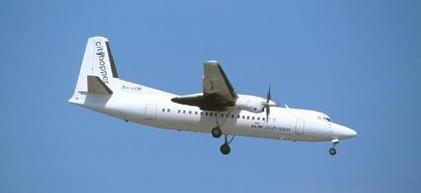

Category: airplanes


In [25]:
# Visualize an image given an image ID.

# Each category orderd alphabetically has numbered images starting from 0, tourchvision concats them all sequentially.

IMG_ID = 2500 # Image ID in range [0, 8676].

image, category = dataset[IMG_ID][0], dataset.categories[dataset[IMG_ID][1]]

display(image)
print("Category:", category)


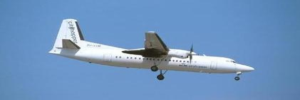

In [26]:
# Resize image to 300 x 100.

from torchvision.transforms import Resize

image = Resize(size=(100, 300))(image)

display(image)

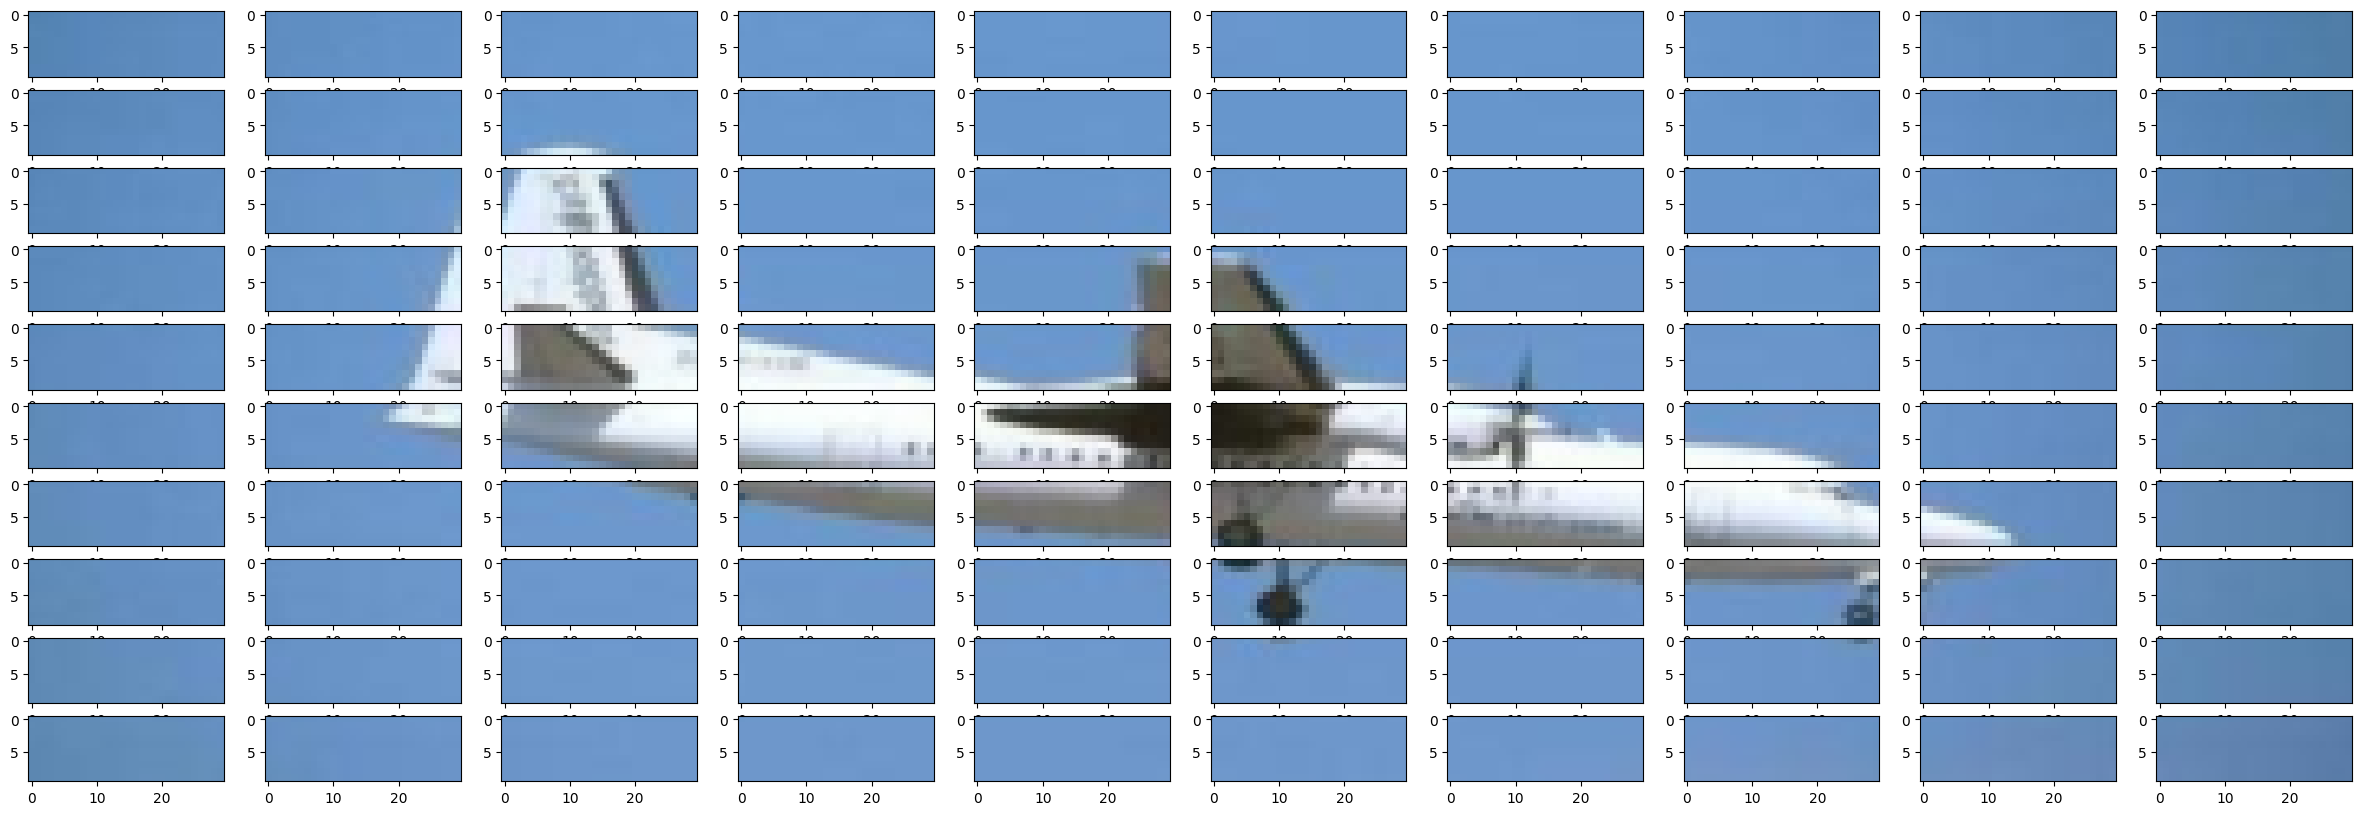

In [107]:
from torchvision.transforms import transforms

# Convert PIL to tensor.

img_tensor = transforms.Compose([transforms.PILToTensor()])(image)

# Partition image into a 10x10 grid (each cell is 30x10).

import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=10, ncols=10, figsize=(30,10))

grid = []

for i in range(10):
    grid.append([])
    for j in range(10):
        grid[-1].append(img_tensor[:, 10*i : 10*(i+1), 30*j : 30*(j+1)])
        axes[i, j].imshow(transforms.ToPILImage()(grid[-1][-1]))

Length of generated color descriptor:  900
tensor([8.9897e+01, 3.4889e+00,        nan, 1.3640e+02, 2.8739e+00,        nan,
        1.8663e+02, 4.2150e+00,        nan, 9.7677e+01, 1.9542e+00,        nan,
        1.4450e+02, 2.0905e+00,        nan, 1.9761e+02, 2.9357e+00,        nan,
        1.0281e+02, 1.2113e+00,        nan, 1.4972e+02, 1.2287e+00,        nan,
        2.0376e+02, 1.2086e+00,        nan, 1.0421e+02, 9.0142e-01,        nan,
        1.5121e+02, 9.0142e-01,        nan, 2.0521e+02, 9.0142e-01,        nan,
        1.0385e+02, 6.9028e-01,        nan, 1.5073e+02, 7.2725e-01,        nan,
        2.0479e+02, 6.6630e-01,        nan, 1.0361e+02, 9.0765e-01, 1.0088e+00,
        1.5009e+02, 5.9270e-01,        nan, 2.0436e+02, 6.4581e-01, 6.9994e-01,
        1.0263e+02, 7.4428e-01,        nan, 1.4963e+02, 7.4428e-01,        nan,
        2.0363e+02, 7.4428e-01,        nan, 9.9267e+01, 1.5151e+00,        nan,
        1.4549e+02, 2.2007e+00,        nan, 1.9983e+02, 1.8883e+00,        na

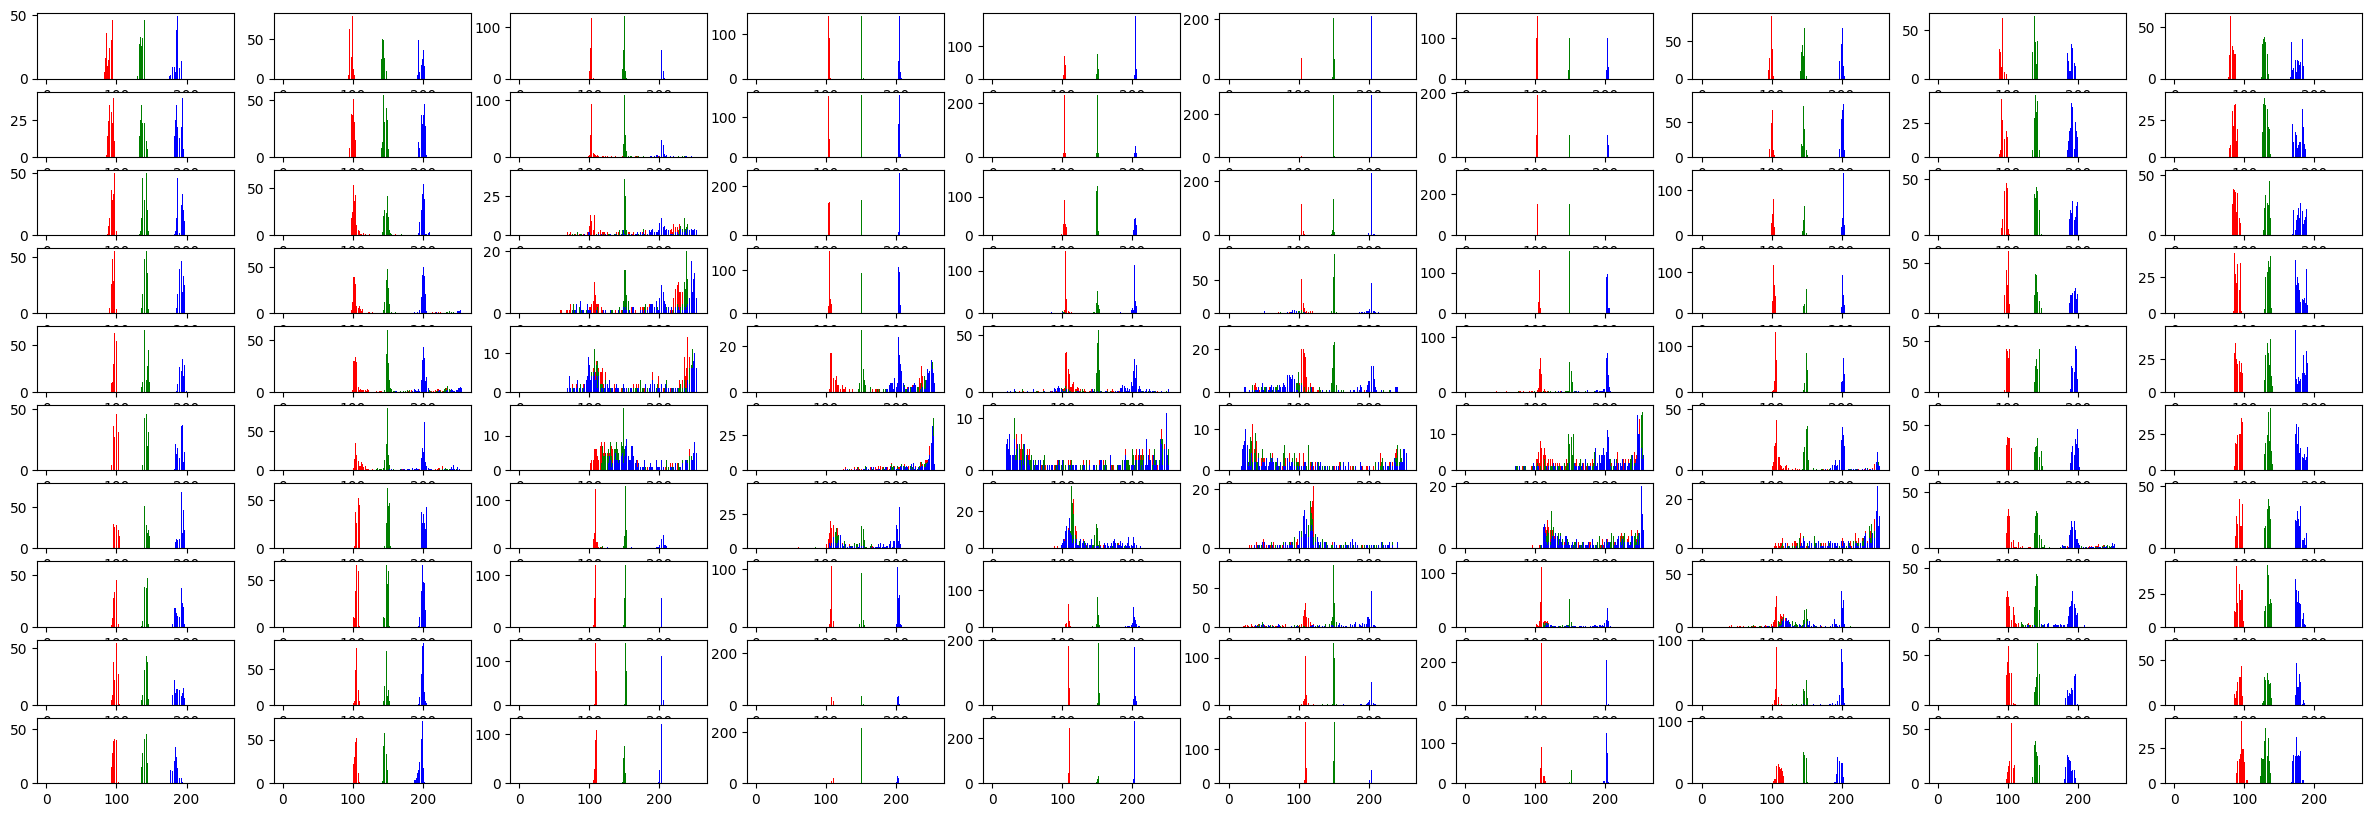

In [114]:
# Color moments (CM10x10).

# Color moments capture the distribution of intensities of each channel (R, G, B).
# In essense, we will be calculating the mean, standard deviation, and skewness of
# each 10x30 (HxW) grid cell of which there are 10x10, for each channel, of which there are 3.
# This results in a feature descriptor of length 10x10x3x3 = 900.

# Each cell tensor's shape is 3 x 10 x 30 (C x H x W)

import torch
fig, axes = plt.subplots(nrows=10, ncols=10, figsize=(30,10))

color_descriptor = []

for i in range(10):
    for j in range(10):

        cell = grid[i][j]

        cell_descriptor = []

        for channel in cell:

            # https://en.wikipedia.org/wiki/Color_moments

            channel_descriptor = []

            mean = channel.float().mean()
            channel_descriptor.append(mean)

            diffs = (channel - mean)

            # As per the source, standard deviation is using population standard deviation
            # as opposed to sample standard deviation (N in the denominator instead
            # of N-1). In other words, it does not use Bessel's correction:
            # https://en.wikipedia.org/wiki/Bessel%27s_correction
            std = diffs.pow(2).mean().pow(1/2)
            channel_descriptor.append(std)

            # This is not Fisher-Pearson Skewness, it is what is expressed on the Wiki
            # page as well as the lecture notes. The reason why I'm doing cube root
            # this way is due to NaNs when taking cube roots of negatives in PyTorch
            # tensors: https://github.com/pytorch/pytorch/issues/25766
            cube_diffs = diffs.pow(3).mean()
            skew = cube_diffs.sign() * cube_diffs.abs().pow(1/3)    
            channel_descriptor.append(skew)

            cell_descriptor.extend(channel_descriptor)

        color_descriptor.extend(cell_descriptor)

        # Displaying histograms:

        hist_red = torch.histc(cell[0].float(), bins=256, min=0, max=255)
        hist_green = torch.histc(cell[1].float(), bins=256, min=0, max=255)
        hist_blue = torch.histc(cell[2].float(), bins=256, min=0, max=255)

        axes[i, j].bar(range(256), hist_red, color='red')
        axes[i, j].bar(range(256), hist_green, color='green')
        axes[i, j].bar(range(256), hist_blue, color='blue')

color_descriptor = torch.tensor(color_descriptor)

print("Length of generated color descriptor: ", len(color_descriptor))
print(color_descriptor)


In [ ]:
# Histograms of oriented gradients (HOG)